<a href="https://colab.research.google.com/github/TaherBenAfia/Fly2/blob/main/work/notebooks/01_first_look_and_discovery.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 1 — Run it, then discover a real truth yourself

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/flyrank-bih/flyrank-ml-internship-starter/blob/main/notebooks/01_first_look_and_discovery.ipynb)

By the end of this notebook you will have:
1. **Run a real ML pipeline** on real (anonymized) search data and watched a learned model beat a hand-written rule.
2. **Rediscovered a real finding yourself** in ~10 lines of pandas.

No prior ML needed. Everything runs on the small anonymized dataset that ships with this repo — no credentials, no private data.

## 0. Setup (Colab or local)
On Colab this clones the repo and installs requirements. Locally it just moves to the repo root.

In [1]:
import os, sys, subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/flyrank-bih/flyrank-ml-internship-starter"
REPO_DIR = "flyrank-ml-internship-starter"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
elif os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")  # move from notebooks/ to the repo root

print("Working dir:", os.getcwd())
assert os.path.exists("data/raw/content_refresh_anonymized.csv"), "starter CSV not found — are you at the repo root?"
print("Starter data found. You're ready.")

Working dir: /content/flyrank-ml-internship-starter
Starter data found. You're ready.


## 1. Run the whole pipeline

This runs `scripts/run_all.py`: prepare features → baseline rule → train 3 models → evaluate → PDF.
It takes ~1 minute on the 30,000-row sample.

In [2]:
# Watch it work — each of the 5 steps prints live as it runs (~1 minute total).
!{sys.executable} scripts/run_all.py



▶ Step 1/5 — Prepare features — clean the data, build the feature vector, define the label
Prepared 30,000 rows from 30,000 raw rows
Wrote /content/flyrank-ml-internship-starter/data/processed/refresh_feature_vector.csv

▶ Step 2/5 — Baseline — a transparent hand-written rule to beat
Wrote baseline queue: /content/flyrank-ml-internship-starter/data/processed/baseline_refresh_queue.csv
Top-50 declining rate (full data, not the evaluated holdout Precision@50): 0.340

▶ Step 3/5 — Train — logistic regression, decision tree, random forest (client-holdout split)
Trained 3 models on 30,000 rows
Split strategy: client_holdout
Best model: random_forest
Wrote predictions: /content/flyrank-ml-internship-starter/data/processed/model_predictions.csv
Wrote model results: /content/flyrank-ml-internship-starter/outputs/model_results.json

▶ Step 4/5 — Evaluate — ranked refresh queue, charts, and the Markdown report
Wrote final refresh queue: /content/flyrank-ml-internship-starter/outputs/refresh_que

### What just happened?
The pipeline ranked every page for "refresh review" two ways: a **hand-written rule baseline** and a **learned model**. Let's compare them on **Precision@50** — of the top 50 pages each says to fix first, how many are actually declining?

In [3]:
import json
res = json.load(open("outputs/model_results.json"))

base = res["baseline"]["baseline_precision_at_50"]
rf   = res["models"]["random_forest"]["precision_at_50"]

print(f"Hand-written rule  Precision@50: {base:.3f}   (~{round(base*50)} of the top 50 right)")
print(f"Random forest      Precision@50: {rf:.3f}   (~{round(rf*50)} of the top 50 right)")
print(f"\nThe learned model roughly {rf/base:.1f}x the rule on this metric.")
print("Validation split used:", res["split_strategy"], "(pages from a client are never in both train and test)")

Hand-written rule  Precision@50: 0.240   (~12 of the top 50 right)
Random forest      Precision@50: 0.740   (~37 of the top 50 right)

The learned model roughly 3.1x the rule on this metric.
Validation split used: client_holdout (pages from a client are never in both train and test)


You just ran a real ML system on real search data and saw a learned ranking beat a fixed rule. Now open `outputs/model_report.md` and skim it — that Markdown report is the *shape* of what your own capstone should produce.

## 2. Discover a real truth yourself

The safest, most satisfying early wins are **things you find in the data** — un-leakable, and they *are* the core lesson. Run the three cells below. Each is ~10 lines of pandas and each overturns a common SEO belief.

Every number is **computed live from the shipped CSV** — nothing is hardcoded.

In [4]:
import pandas as pd, numpy as np
df = pd.read_csv("data/raw/content_refresh_anonymized.csv")
print(df.shape[0], "rows,", df.shape[1], "columns")
df.head(3)

30000 rows, 44 columns


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9


### Discovery A — "High search volume means more traffic." Does it?

In [5]:
corr = df["search_volume"].corr(df["impressions_90d"])
print(f"Correlation between search_volume and impressions_90d: {corr:.3f}")
print("Near zero -> keyword search volume barely predicts the traffic a page actually gets.")

Correlation between search_volume and impressions_90d: 0.001
Near zero -> keyword search volume barely predicts the traffic a page actually gets.


### Discovery B — the CTR cliff by position
Click-through rate is not flat: it collapses as you move down the results.

position_tier
page_1      0.3548
top_3       0.3341
striking    0.2558
page_3_5    0.1424
deep        0.0554


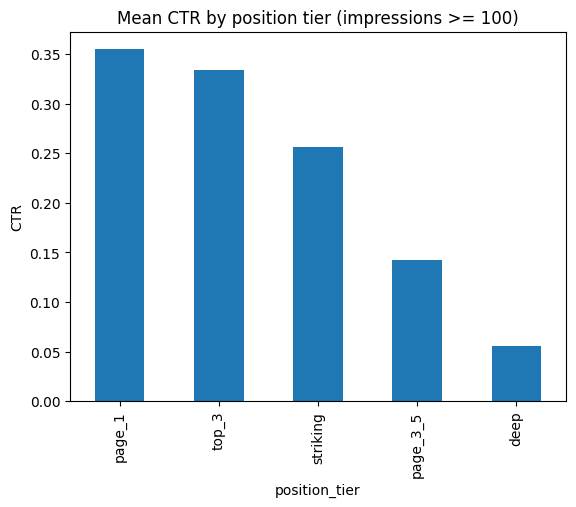

In [6]:
visible = df[df["impressions_90d"] >= 100]
ctr_by_pos = visible.groupby("position_tier")["ctr"].mean().sort_values(ascending=False)
print(ctr_by_pos.round(4).to_string())
ctr_by_pos.plot(kind="bar", title="Mean CTR by position tier (impressions >= 100)", ylabel="CTR");

### Discovery C — is longer content the lever?
Compare word count for **declining** vs **growing** pages.

In [7]:
wc = df.groupby("trend_direction")["word_count"].median()
print(wc.round(0).to_string())
print("\n'down' vs 'up' pages have almost the same median word count -> length is not the lever.")

trend_direction
down      2909.0
flat      2698.0
new       2239.0
stable    2912.0
up        2848.0

'down' vs 'up' pages have almost the same median word count -> length is not the lever.


## 3. 🔧 Your turn

Pick **one** of these and write a few lines below. This is your Week-1 discovery — you'll reference it in your Week-1 research-question write-up (on the InternHQ board).

- Redo Discovery A but only for pages with `impressions_90d > 0` — does the correlation change?
- In Discovery B, which `content_type` has the worst CTR *at the same position tier*?
- Find another belief to test: does `content_age_days` relate to `trend_direction`? Does `avg_position` relate to `ctr`?

**Rules:** describe what you observe as *observed / directional* — never "I proved Google's algorithm." Keep client data out of anything you publish.

In [8]:
# Your discovery here
#DISCOVERY C : Find another belief to test: does content_age_days relate to trend_direction? Does avg_position relate to ctr?
df.columns

Index(['content_id', 'client_id', 'search_volume', 'competition',
       'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count',
       'char_count', 'provider_used', 'model_used', 'impressions_90d',
       'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d',
       'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d',
       'days_with_impressions', 'days_with_sessions', 'impressions_last_30d',
       'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d',
       'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier',
       'age_tier_order', 'days_since_last_update', 'freshness_tier',
       'word_count_tier', 'char_count_tier', 'ctr', 'avg_position',
       'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'impression_tier',
       'position_tier', 'trend_direction', 'trend_pct'],
      dtype='object')

#Feature Engineering

In [9]:
df.head(5)

,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


In [10]:
df["content_type"].unique()

array(['keyword article', 'feedly article', 'comparison article'],
      dtype=object)

#Split INTO Feature Groups

In [11]:
FEATURE_GROUPS = {
    "identifiers": [
        "content_id", "client_id"
    ],

    "keyword_context": [
        "search_volume", "competition", "competition_level",
        "cpc", "content_type", "main_intent"
    ],

    "content_properties": [
        "word_count", "char_count", "word_count_tier", "char_count_tier",
        "provider_used", "model_used",
        "content_age_days", "age_tier", "age_tier_order",
        "days_since_last_update", "freshness_tier"
    ],

    "serp_presence": [
        "impressions_90d", "impressions_last_30d", "impressions_prev_30d",
        "days_with_impressions", "impression_tier",
        "avg_position", "position_tier"
    ],

    "recent_trend_windows": [
        "impressions_last_30d", "clicks_last_30d", "sessions_last_30d",
        "impressions_prev_30d", "clicks_prev_30d", "sessions_prev_30d",
        "trend_direction", "trend_pct"
    ],

    "click_transition": [
        "clicks_90d", "clicks_last_30d", "clicks_prev_30d", "ctr"
    ],

    "traffic_volume": [
        "pageviews_90d", "sessions_90d", "sessions_last_30d",
        "sessions_prev_30d", "users_90d", "days_with_sessions"
    ],

    "engagement": [
        "engaged_sessions_90d", "engagement_rate",
        "scroll_events_90d", "scroll_rate"
    ],

    "ai_referral": [
        "ai_sessions_90d", "ai_traffic_pct"
    ],

    "before_click": [
        "search_volume", "competition", "competition_level", "cpc",
        "content_type", "main_intent",
        "word_count", "char_count", "word_count_tier", "char_count_tier",
        "provider_used", "model_used",
        "content_age_days", "age_tier", "age_tier_order",
        "days_since_last_update", "freshness_tier",
        "impressions_90d", "impressions_last_30d", "impressions_prev_30d",
        "days_with_impressions", "impression_tier",
        "avg_position", "position_tier",
        "trend_direction", "trend_pct"
    ],

    "after_click": [
        "pageviews_90d", "sessions_90d", "sessions_last_30d", "sessions_prev_30d",
        "users_90d", "days_with_sessions",
        "engaged_sessions_90d", "engagement_rate",
        "scroll_events_90d", "scroll_rate",
        "ai_sessions_90d", "ai_traffic_pct"
    ],
}

In [12]:
def get_feature_subset(df: pd.DataFrame, group: str, keep_ids: bool = True) -> pd.DataFrame:

    if group not in FEATURE_GROUPS:
        raise ValueError(
            f"Unknown group '{group}'. Available groups:\n"
            + ", ".join(FEATURE_GROUPS.keys())
        )

    cols = FEATURE_GROUPS[group]

    if keep_ids:
        id_cols = ["content_id", "client_id"]
        cols = id_cols + [c for c in cols if c not in id_cols]

    cols = [c for c in cols if c in df.columns]
    return df[cols]

In [13]:
trend_df = get_feature_subset(df, "recent_trend_windows")
trend_df.head()

traffic_engagement_df = get_feature_subset(df, "traffic_volume").merge(
    get_feature_subset(df, "engagement"),
    on=["content_id", "client_id"]
)
traffic_engagement_df.head()

,content_id,client_id,pageviews_90d,sessions_90d,sessions_last_30d,sessions_prev_30d,users_90d,days_with_sessions,engaged_sessions_90d,engagement_rate,scroll_events_90d,scroll_rate
0,content_304f48230142,client_f369cb89fc,22,17,2,9,16,13,1,5.88,1,4.55
1,content_a1fb4e703a9e,client_4e07408562,10,9,3,2,9,9,0,0.00,1,10.00
2,content_9aa793d4d895,client_7f2253d7e2,14,11,1,3,11,11,0,0.00,4,28.57
3,content_331d6c4de07b,client_19581e27de,87,78,35,26,75,51,1,1.28,3,3.45
4,content_d99b7a2d90ca,client_3fdba35f04,177,145,14,9,144,33,0,0.00,43,24.29


#Find another belief to test: does content_age_days relate to trend_direction? Does avg_position relate to ctr?


In [14]:
print(df["content_age_days"].unique().max())
print(df["content_age_days"].unique().min())

564
90


#Whats the trend direction to the content age ?

In [15]:
df.groupby('trend_direction')['content_age_days'].describe()

,count,mean,std,min,25%,50%,75%,max
trend_direction,,,,,,,,
down,16262.0,236.178637,126.964539,90.0,126.0,216.0,313.0,557.0
flat,1152.0,245.889757,117.499820,90.0,133.0,231.0,322.0,545.0
new,2236.0,238.718247,100.288997,90.0,137.0,279.0,310.0,517.0
stable,5962.0,295.439953,138.999896,90.0,148.0,300.0,441.0,564.0
up,4388.0,288.478806,144.481199,90.0,139.0,291.5,438.0,557.0


In [16]:
import plotly.express as px
df_content_trend = df.loc[:, ["content_age_days", "trend_direction"]]
fig = px.bar(df_content_trend, x="content_age_days", y="trend_direction",color_discrete_sequence=['red'])
fig.show()

In [17]:
fig = px.histogram(df_content_trend, x="content_age_days", color="trend_direction", marginal="rug", histnorm='density',
                   title='Density Plot of Content Age by Trend Direction')
fig.show()

# **INSIGHT** : Recent Content seems to have down-ish trend compared to older Content which is quite reasonable

In [18]:
df_refresh = pd.read_csv("/content/flyrank-ml-internship-starter/outputs/refresh_queue.csv")
df_refresh.head()

,final_rank,content_id,client_id,final_refresh_score,best_model_name,best_model_probability,baseline_refresh_score,confidence,suggested_action,final_reason_codes,...,word_count,trend_direction,competition_level,content_type,main_intent,age_tier,freshness_tier,word_count_tier,impression_tier,position_tier
0,1,content_1f080331fa2b,client_3fdba35f04,81.734212,random_forest,0.783472,0.844481,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|low...,...,1404.0,down,MEDIUM,keyword article,informational,91-180,91-180,1000-2000,good,page_1
1,2,content_d6570c51c9bd,client_3fdba35f04,81.603243,random_forest,0.849842,0.695884,medium,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,...,1362.0,down,MEDIUM,keyword article,informational,91-180,91-180,1000-2000,moderate,striking
2,3,content_6aa43079fb0c,client_3fdba35f04,81.544618,random_forest,0.789490,0.825477,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,...,1457.0,down,LOW,keyword article,informational,91-180,91-180,1000-2000,good,page_1
3,4,content_72e800a9c214,client_3fdba35f04,81.169731,random_forest,0.776297,0.842545,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,...,1371.0,down,MEDIUM,keyword article,commercial,91-180,91-180,1000-2000,good,page_1
4,5,content_e04eb9549989,client_3fdba35f04,80.957565,random_forest,0.816010,0.749468,medium,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,...,1408.0,down,LOW,keyword article,informational,91-180,91-180,1000-2000,good,page_1


In [19]:
from typing import List
import pandas as pd

def get_final_reason_codes_df(df: pd.DataFrame) -> pd.DataFrame:
  required_cols = ["final_reason_codes", "trend_direction", "content_age_days","suggested_action"]
  for col in required_cols:
      if col not in df.columns:
          raise ValueError(f"Missing required column: {col}")
  reasons_split = df['final_reason_codes'].str.split('|', expand=True)
  all_unique_reasons = pd.unique(reasons_split.values.ravel())
  all_unique_reasons = [r for r in all_unique_reasons if pd.notna(r)]

  reason_features_df = pd.DataFrame(0, index=df.index, columns=all_unique_reasons)

  for reason_col in reasons_split.columns:
      for reason in all_unique_reasons:
          reason_features_df.loc[reasons_split[reason_col] == reason, reason] = 1

  reason_features_df = reason_features_df.groupby(level=0, axis=1).max()


  core_features = df[['trend_direction', 'content_age_days','suggested_action']].copy()

  final_df = pd.concat([core_features, reason_features_df], axis=1)

  return final_df

In [20]:
df_final = get_final_reason_codes_df(df_refresh)
df_final.head()

/tmp/ipykernel_1109/938933224.py:19: FutureWarning:

DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.



,trend_direction,content_age_days,suggested_action,ctr_review_candidate,declining_with_demand,engagement_review_candidate,general_refresh_review,low_ctr_visible_page,low_engagement_visible_page,model_decline_risk,page_one_decay_risk,stale_visible_page,thin_visible_page,visible_model_opportunity
0,down,165,refresh_and_review_ctr,1,1,1,0,1,1,1,0,0,0,1
1,down,165,refresh_and_review_ctr,1,1,0,0,1,0,1,0,0,0,1
2,down,139,refresh_and_review_ctr,1,1,0,0,1,0,1,0,0,0,1
3,down,139,refresh_and_review_ctr,1,1,0,0,1,0,1,0,0,0,1
4,down,131,refresh_and_review_ctr,1,1,0,0,1,0,1,0,0,0,1


In [21]:
df_final[:50].groupby('trend_direction')["content_age_days"].mean()

,content_age_days
trend_direction,
down,145.22449
stable,165.00000


the content that has survived longest that tends to be holding steady or growing.
content_age_days spans over a year, meaning different ages likely correspond to different publish months/seasons, and no calendar field survived anonymization to test this directly.

# Statistical test: does content_age_days have an effect on trend_direction?

Plan: split by `trend_direction` -> rank all `content_age_days` values pooled -> Kruskal-Wallis (k=5, df=4) -> if significant, pairwise Mann-Whitney U with Bonferroni correction -> effect size (epsilon-squared).

In [22]:
from scipy import stats
from itertools import combinations
import numpy as np

groups = df.groupby('trend_direction')['content_age_days']
group_arrays = [vals.dropna().values for _, vals in groups]
group_names = [name for name, _ in groups]

for name, arr in zip(group_names, group_arrays):
    print(f"{name:8s} n={len(arr):6d}  mean={arr.mean():7.1f}  median={np.median(arr):7.1f}")

down     n= 16262  mean=  236.2  median=  216.0
flat     n=  1152  mean=  245.9  median=  231.0
new      n=  2236  mean=  238.7  median=  279.0
stable   n=  5962  mean=  295.4  median=  300.0
up       n=  4388  mean=  288.5  median=  291.5


In [23]:
H, p_value = stats.kruskal(*group_arrays)
df_k = len(group_arrays) - 1  # degrees of freedom = k - 1

print(f"H statistic: {H:.3f}")
print(f"df: {df_k}")
print(f"p-value: {p_value:.6g}")

H statistic: 982.034
df: 4
p-value: 2.79323e-211


# **INSIGHT**: H = 982.03, df = 4, p ~ 2.79e-211 ( H > 14.86 ( extracted from Chi-Squarred table) -> reject H0. The 5 trend_direction groups do not share the same content_age_days distribution. Something real is going on -- next, lets find out which pairs differ.

In [24]:
alpha = 0.05
pairs = list(combinations(range(len(group_names)), 2))
n_tests = len(pairs)
alpha_corrected = alpha / n_tests
print(f"pairwise comparisons: {n_tests}, bonferroni-corrected alpha: {alpha_corrected:.5f}")

results = []
for i, j in pairs:
    name_i, name_j = group_names[i], group_names[j]
    arr_i, arr_j = group_arrays[i], group_arrays[j]
    u_stat, p_raw = stats.mannwhitneyu(arr_i, arr_j, alternative='two-sided')
    results.append({
        'group_1': name_i, 'group_2': name_j,
        'median_1': np.median(arr_i), 'median_2': np.median(arr_j),
        'p_raw': p_raw,
        'significant_after_correction': p_raw < alpha_corrected
    })

results_df = pd.DataFrame(results).sort_values('p_raw')
results_df

pairwise comparisons: 10, bonferroni-corrected alpha: 0.00500


,group_1,group_2,median_1,median_2,p_raw,significant_after_correction
2,down,stable,216.0,300.0,4.808621e-166,True
3,down,up,216.0,291.5,1.448960e-86,True
7,new,stable,279.0,300.0,5.084438e-55,True
8,new,up,279.0,291.5,4.805901e-32,True
5,flat,stable,231.0,300.0,1.427616e-22,True
6,flat,up,231.0,291.5,8.710557e-13,True
1,down,new,216.0,279.0,1.539340e-06,True
0,down,flat,216.0,231.0,5.848200e-06,True
9,stable,up,300.0,291.5,3.627761e-03,True
4,flat,new,231.0,279.0,5.501319e-02,False


# **INSIGHT**: 9 of 10 pairs stay significant after Bonferroni correction (only flat vs new fails, p=0.055). down vs stable is the strongest separation (p~4.8e-166), consistently down/new/flat sit apart from stable/up -- matches the earlier hypothesis, not just noise.

In [25]:
n_total = sum(len(a) for a in group_arrays)
epsilon_squared = (H - len(group_arrays) + 1) / (n_total - len(group_arrays))
print(f"epsilon-squared = {epsilon_squared:.4f}")
# <0.01 negligible | 0.01-0.06 small | 0.06-0.14 medium | >0.14 large

epsilon-squared = 0.0326


# **CONCLUSION**: content_age_days has a statistically real, consistent, and specifically-localized effect on trend_direction (down/new/flat skew younger vs stable/up), confirmed by Kruskal-Wallis + Bonferroni-corrected pairwise tests. BUT epsilon-squared = 0.033 = a small effect -- age alone is a weak lever, not a dominant driver (consistent with its 4th-place model feature importance, 0.095). Still association, not causation: seasonality (no date field survived anonymization) and survivorship (weak content may decline earlier, leaving only durable content in the older bins) remain untested alternative explanations.

# **avg_position vs ctr**

In [26]:
df.head()

,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


In [27]:
df.groupby("position_tier")["ctr"].describe()

,count,mean,std,min,25%,50%,75%,max
position_tier,,,,,,,,
deep,1319.0,0.150212,1.612777,0.0,0.0,0.00,0.00,50.00
page_1,11814.0,0.652467,3.088921,0.0,0.0,0.16,0.41,100.00
page_3_5,7242.0,0.222484,2.147958,0.0,0.0,0.03,0.17,100.00
striking,7304.0,0.323239,1.387226,0.0,0.0,0.11,0.30,33.33
top_3,2321.0,1.483611,8.187178,0.0,0.0,0.00,0.00,100.00


In [28]:
print(df.describe())

       search_volume   competition           cpc    word_count     char_count  \
count   27532.000000  27532.000000  27532.000000  22301.000000   22301.000000   
mean      158.882391      0.146954      0.485342   3107.760325   20665.277835   
std      1518.270825      0.285241      2.101560   1452.382598   10115.344042   
min         0.000000      0.000000      0.000000      8.000000      40.000000   
25%         0.000000      0.000000      0.000000   2413.000000   15644.000000   
50%        10.000000      0.000000      0.000000   2877.000000   19116.000000   
75%        20.000000      0.130000      0.000000   3666.000000   24011.000000   
max     74000.000000      1.000000    100.360000   9546.000000  111158.000000   

       impressions_90d    clicks_90d  pageviews_90d  sessions_90d  \
count     30000.000000  30000.000000   30000.000000  30000.000000   
mean       5200.366300     16.097333      49.942467     37.066633   
std       16838.019547     75.076958     152.101430    107.0691

In [41]:
df_intent_analysis = df.loc[:, ["main_intent", "position_tier", "avg_position", "ctr"]]
df_intent_analysis = df_intent_analysis.groupby(["main_intent", "position_tier"]).mean().reset_index()
df_intent_analysis.head()

,main_intent,position_tier,avg_position,ctr
0,commercial,deep,65.341228,0.096886
1,commercial,page_1,6.574217,0.352316
2,commercial,page_3_5,30.866613,0.155784
3,commercial,striking,14.413212,0.251805
4,commercial,top_3,1.489496,0.367227


In [30]:
corr = df["ctr"].corr(df["avg_position"])
print(f"Correlation between avg_pos and ctr: {corr:.3f}")
print("Near zero -> keyword search volume barely predicts the traffic a page actually gets.")

Correlation between avg_pos and ctr: -0.073
Near zero -> keyword search volume barely predicts the traffic a page actually gets.


In [43]:
import plotly.express as px

# Define a custom order for position_tier for better visualization
position_order = ['top_3', 'page_1', 'striking', 'page_3_5', 'deep']
df_intent_analysis['position_tier'] = pd.Categorical(df_intent_analysis['position_tier'], categories=position_order, ordered=True)
# Sort the DataFrame to ensure consistent plotting order
df_intent_analysis_sorted = df_intent_analysis.sort_values(['main_intent', 'position_tier'])

fig = px.bar(
    df_intent_analysis_sorted,
    x='position_tier',
    y='ctr',
    color='main_intent',
    barmode='group', # Group bars for each main_intent side-by-side
    title='Mean CTR by Position Tier and Main Intent',
    labels={'ctr': 'Mean CTR', 'position_tier': 'Position Tier', 'main_intent': 'Main Intent'},
    hover_data=['avg_position'] # Show avg_position on hover
)
fig.show()

### Plotting Mean CTR by Position Tier and Main Intent using Matplotlib/Seaborn

While Plotly provides interactive charts, `matplotlib` and `seaborn` are also excellent for creating static visualizations. Below is an example of how to recreate the grouped bar chart using these libraries.

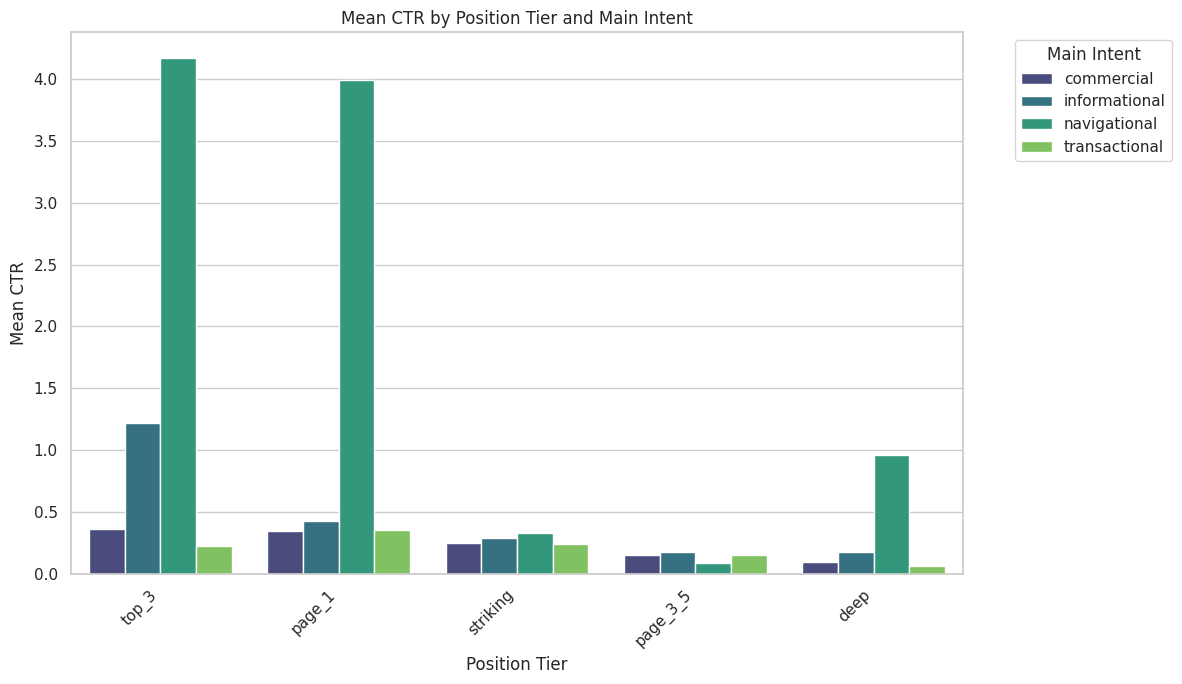

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 7))
sns.barplot(
    data=df_intent_analysis_sorted,
    x='position_tier',
    y='ctr',
    hue='main_intent',
    palette='viridis'
)

plt.title('Mean CTR by Position Tier and Main Intent')
plt.xlabel('Position Tier')
plt.ylabel('Mean CTR')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Main Intent', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#These are all expected results, ( although too much outliers/noise is making the corrr go insane) even the main  intent hue was expected or sure to be like that so my main goal now is to actually hit that review ctr action that appears to be over-chosen as an action, hence we're building a ctr_gap feature that relies on expected ctr values compared to their actual values for each row/page

In [45]:
baseline = df.groupby('position_tier')['ctr'].mean()
df['expected_ctr'] = df['position_tier'].map(baseline)
df['ctr_gap'] = df['ctr'] - df['expected_ctr']

In [49]:
df.groupby('position_tier')['ctr_gap'].mean().head()

,ctr_gap
position_tier,
deep,-8.059428e-18
page_1,1.917094e-18
page_3_5,5.714383e-18
striking,-7.432901e-18
top_3,1.817685e-18


#We can further reshape it by changing the expected values of Ctr using a smoother line , a regression between ctr and avg_position that has finer calibration of ranking

In [58]:
from scipy.stats import spearmanr
df.loc[df['avg_position'] == 0, 'avg_position'] = np.nan
fit_df_raw = df.dropna(subset=['avg_position', 'ctr']).copy()
fit_df_raw['log_position'] = np.log(fit_df_raw['avg_position'])
slope_raw, intercept_raw = np.polyfit(fit_df_raw['log_position'], fit_df_raw['ctr'], deg=1)
pred_raw = intercept_raw + slope_raw * fit_df_raw['log_position']
ss_res = np.sum((fit_df_raw['ctr'] - pred_raw) ** 2)
ss_tot = np.sum((fit_df_raw['ctr'] - fit_df_raw['ctr'].mean()) ** 2)
r2_raw = 1 - ss_res / ss_tot
rho_raw, p_raw = spearmanr(fit_df_raw['avg_position'], fit_df_raw['ctr'])
print("STEP 1: unfiltered fit (includes low-volume noisy rows)")
print(f"rows used: {len(fit_df_raw)}")
print(f"ctr = {intercept_raw:.4f} + {slope_raw:.4f} * log(avg_position)")
print(f"R-squared: {r2_raw:.4f}")
print(f"Spearman rho: {rho_raw:.4f}, p={p_raw:.3g}")

STEP 1: unfiltered fit (includes low-volume noisy rows)
rows used: 28795
ctr = 1.8187 + -0.5212 * log(avg_position)
R-squared: 0.0185
Spearman rho: -0.2342, p=0


In [59]:
extreme = fit_df_raw[fit_df_raw['ctr'] >= 99]
print(f"\nRows with ctr >= 99: {len(extreme)}")
print(extreme[['content_id', 'avg_position', 'ctr', 'impressions_90d', 'clicks_90d']].to_string(index=False))
print("\n=> every one of these has impressions_90d == 1 and clicks_90d == 1:")
print("   a single random click inflating the ratio to 100%, not a real signal.")

low_volume_count = (fit_df_raw['impressions_90d'] < 10).sum()
print(f"\nRows with impressions_90d < 10: {low_volume_count} of {len(fit_df_raw)}")


Rows with ctr >= 99: 10
          content_id  avg_position   ctr  impressions_90d  clicks_90d
content_006b16e7a2e7           1.0 100.0                1           1
content_3f3576c295f5           1.0 100.0                1           1
content_cfa4d9f1bf0a          25.0 100.0                1           1
content_bf398aa7400e           2.0 100.0                1           1
content_98458bafe297           1.0 100.0                1           1
content_4272d3a330a3           8.0 100.0                1           1
content_a84e013a5f94           9.0 100.0                1           1
content_6016b918a48f          30.0 100.0                1           1
content_bc2c0c7243df           1.0 100.0                1           1
content_a8cee66e4788           2.0 100.0                1           1

=> every one of these has impressions_90d == 1 and clicks_90d == 1:
   a single random click inflating the ratio to 100%, not a real signal.

Rows with impressions_90d < 10: 2543 of 28795


In [62]:
clean = df.dropna(subset=['avg_position', 'ctr']).copy()
clean = clean[clean['impressions_90d'] >= 100].copy()
clean['log_position'] = np.log(clean['avg_position'])
slope, intercept = np.polyfit(clean['log_position'], clean['ctr'], deg=1)
pred = intercept + slope * clean['log_position']
ss_res = np.sum((clean['ctr'] - pred) ** 2)
ss_tot = np.sum((clean['ctr'] - clean['ctr'].mean()) ** 2)
r2 = 1 - ss_res / ss_tot
rho, p = spearmanr(clean['avg_position'], clean['ctr'])
print("STEP 2: filtered fit (impressions_90d >= 100)")
print(f"rows used: {len(clean)} of {len(df)}")
print(f"ctr = {intercept:.4f} + {slope:.4f} * log(avg_position)")
print(f"R-squared: {r2:.4f}")
print(f"Spearman rho: {rho:.4f}, p={p:.3g}")
print("\nExpected CTR at reference positions:")
for pos in [1, 3, 5, 10, 20, 50, 100]:
    exp = max(0, intercept + slope * np.log(pos))
    print(f"  position {pos:>3}: expected ctr = {exp:.3f}")


STEP 2: filtered fit (impressions_90d >= 100)
rows used: 22006 of 30000
ctr = 0.5794 + -0.1264 * log(avg_position)
R-squared: 0.0619
Spearman rho: -0.3618, p=0

Expected CTR at reference positions:
  position   1: expected ctr = 0.579
  position   3: expected ctr = 0.440
  position   5: expected ctr = 0.376
  position  10: expected ctr = 0.288
  position  20: expected ctr = 0.201
  position  50: expected ctr = 0.085
  position 100: expected ctr = 0.000


In [63]:
clean['expected_ctr'] = (intercept + slope * clean['log_position']).clip(lower=0)  # ctr can't be negative
clean['ctr_gap'] = clean['ctr'] - clean['expected_ctr']
print("STEP 3: ctr_gap — top under/overperformers")
print("\nTop 10 UNDERperformers (good position, weak clicks despite real volume):")
under = clean.nsmallest(10, 'ctr_gap')[
    ['content_id', 'avg_position', 'ctr', 'expected_ctr', 'ctr_gap', 'impressions_90d']
]
print(under.to_string(index=False))
print("\nTop 10 OVERperformers (beating expected CTR for their position):")
over = clean.nlargest(10, 'ctr_gap')[
    ['content_id', 'avg_position', 'ctr', 'expected_ctr', 'ctr_gap', 'impressions_90d']
]
print(over.to_string(index=False))

STEP 3: ctr_gap — top under/overperformers

Top 10 UNDERperformers (good position, weak clicks despite real volume):
          content_id  avg_position  ctr  expected_ctr   ctr_gap  impressions_90d
content_7288a4d4c198           0.1 0.00      0.870473 -0.870473              174
content_7247c9f3c142           0.2 0.07      0.782840 -0.712840             2695
content_baaedabd1d2f           0.4 0.00      0.695208 -0.695208              220
content_d0351144852b           0.6 0.00      0.643946 -0.643946              884
content_844ebbb67a38           0.7 0.00      0.624457 -0.624457              216
content_7e97f31ba9bb           0.7 0.00      0.624457 -0.624457              603
content_0d9c0ed65840           0.8 0.00      0.607575 -0.607575              382
content_2a57f2016a14           0.6 0.04      0.643946 -0.603946             2324
content_637107baa450           0.7 0.04      0.624457 -0.584457             2495
content_ffca1716a06b           1.0 0.00      0.579364 -0.579364          

In [64]:
clean['expected_ctr_tier'] = clean.groupby('position_tier')['ctr'].transform('mean')
clean['ctr_gap_tier'] = clean['ctr'] - clean['expected_ctr_tier']
print("STEP 4: regression-gap vs tier-average-gap agreement")
print("Pearson correlation between the two gap methods:",
      clean['ctr_gap'].corr(clean['ctr_gap_tier']))
print("Spearman correlation between the two gap methods:",
      clean['ctr_gap'].corr(clean['ctr_gap_tier'], method='spearman'))

clean['rank_regression'] = clean['ctr_gap'].rank()
clean['rank_tier'] = clean['ctr_gap_tier'].rank()
clean['rank_diff'] = (clean['rank_regression'] - clean['rank_tier']).abs()
print("Mean absolute rank difference:", clean['rank_diff'].mean())
print("Rows shifting more than 5,000 ranks between methods:", (clean['rank_diff'] > 5000).sum())

STEP 4: regression-gap vs tier-average-gap agreement
Pearson correlation between the two gap methods: 0.9945575583466966
Spearman correlation between the two gap methods: 0.9769769477878741
Mean absolute rank difference: 956.8900754339726
Rows shifting more than 5,000 ranks between methods: 114


#Naive full-dataset fit: R²=0.019, barely any relationship. Traced to 2,500+ rows with under 10 impressions producing meaningless ratios (e.g. 1 click / 1 impression = "100% CTR").After filtering to impressions_90d ≥ 100: R²=0.062, Spearman=-0.362 — improved, still small at the individual-page level, even though the group-level tier averages looked like a clean staircase.Built ctr_gap (actual CTR − regression-predicted CTR for that exact position) as a row-level feature — produces a ranked, actionable list of pages beating or missing expectations for their rank, rather than restating the known aggregate curve.

### Save your work
**Colab:** *File → Save a copy in GitHub* (writes to your own repo — that's your submission) and *File → Save a copy in Drive* (so the session doesn't evaporate).

Next: `02_your_first_readable_model.ipynb` — where the model becomes a rule you can read.